# mechanism_viewer examples

## Use simple viewers for missing data profiling
This notebook shows how to use `plot_missing_rate()` and `build_distribution_of_missingness()` from `viewer_simple.py`.

### 1. Generate synthetic datasets with missing values

For this module, two datasets will be generated.

The first dataset, `data_num`, will only have numeric columns.

The second dataset, `data_mix`, will have both numeric columns and non-numeric columns. This dataset will be useful to show how that `build_distribution_of_missingness()` handles non-numeric columns with `countplot()`.

In [2]:
from mechanism_viewer import generate_dataset_with_missing_data, apply_missing_data, ColType

data_num = generate_dataset_with_missing_data(100, [ColType.CONTINUOUS, ColType.CONTINUOUS, ColType.DISCRETE,
                                                    ColType.CONTINUOUS], 1, ["MAR", "MCAR", "MCAR"], [0.2, 0.4, 0.4])

display(data_num.head(10))

,Col1,Col2,Col3,Col4
0,0.496714,-1.415371,<NA>,NaN
1,-0.138264,-0.420645,<NA>,NaN
2,0.647689,-0.342715,3,2.569927
3,1.523030,NaN,<NA>,-1.107104
4,-0.234153,-0.161286,<NA>,1.388582
5,-0.234137,0.404051,<NA>,-2.659351
6,1.579213,NaN,5,-2.078377
7,0.767435,NaN,5,-1.240640
8,-0.469474,0.257550,4,NaN
9,0.542560,-0.074446,3,0.203702


In [28]:
import pandas as pd

data_mix = pd.DataFrame({
    "color_col": ["blue", "yellow", "green", "black", "purple", "purple", "blue"],
    "numeric_col": [10, 20, 30, 20, 10, 20, 10],
    "fruit_col": ["apple", "banana", "apple", "orange", "banana", "banana", "orange"],
    "animal_col": ["cat", "dog", "dog", "fish", "cat", "dog", "dog"]
})

data_mix = apply_missing_data(data_mix, 1, ["MAR","MCAR","MCAR"], [0.2,0.4, 0.4])

display(data_mix.head(10))

,color_col,numeric_col,fruit_col,animal_col
0,blue,10.0,apple,cat
1,yellow,NaN,NaN,NaN
2,green,30.0,apple,dog
3,black,20.0,orange,fish
4,purple,10.0,NaN,cat
5,purple,20.0,banana,NaN
6,blue,10.0,orange,dog


### 2. Plot missing rate with `plot_missing_rate()`

The function `plot_missing_rate()` plots the missing rate of each column in the given dataset. This is useful, as sometimes columns with similar missing rates may have similar missing data pattern. For example, if the dataset has multiple columns with the same missing rate, it is likely that what is causing one of the columns to have missing values may be the same for the other columns. 

The function returns a `(figure, axis)` tuple, so that the user can adapt the plot to their wish. In addition, by setting `display_plot=True`, the function will also display the plot inside the notebook.

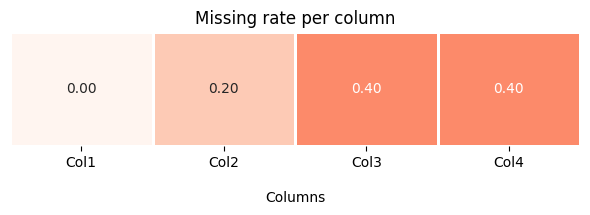

In [4]:
from mechanism_viewer import plot_missing_rate

fig_missing_rate, ax_missing_rate = plot_missing_rate(data_num, display_plot=True)

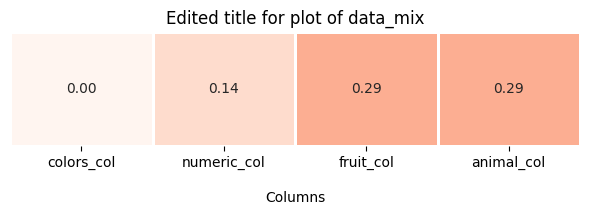

In [9]:
fig_missing_rate_mix, ax_missing_rate_mix = plot_missing_rate(data_mix, display_plot=False)

ax_missing_rate_mix.set_title("Edited title for plot of data_mix")
fig_missing_rate_mix

### 3. Build distributions conditioned on missingness

The function `build_distribution_of_missingness()` creates one plot per column (excluding `missing_col`).
Essentially, each plot shows the distribution of each column based on the missingness of `missing_col`.
If the existence of red bars appear throughout the plot, then missing_col does not see any relationship
with the column at hand, in regards to the way its missing values appear. On the other hand, if most
red bars appear in a zone of the plot, then it is likely that missing_col has a MAR missing mechanism, and
depends on the column at hand.

This function also returns a flat tuple `(fig1, ax1, fig2, ax2, ..., figN, axN)`, where each pair of figure and axes represents one plot of a column. This tuple can be used to retrieve the desired plots, so that the user can adapt them to their wish. In addition, by setting `display_plot=True`, the function will also display every plot inside the notebook.


Since `data_num` has 3 columns with missing data, any of those can work to be `missing_col`. In this example, Col2 will be used.

> Note: The `missing_col` must contain at least one missing value, so that the plotting can be useful.

In [22]:
from mechanism_viewer import build_distribution_of_missingness

target_missing_col = "Col2"

plots = build_distribution_of_missingness(data_num, target_missing_col, display_plot=False)

print(f"Number of returned objects: {len(plots)}")

Number of returned objects: 6


> Note: The dataset has 4 columns: Col1, Col2, Col3, Col4. If Col2 is used for the plotting of the other columns, then the function will return 3 plots: Col1 distribution using missingness of Col2, Col3 distribution using missingness of Col2, Col4 distribution using missingness of Col2. Since each plot has 2 objects, then the function returns 6 total objects.

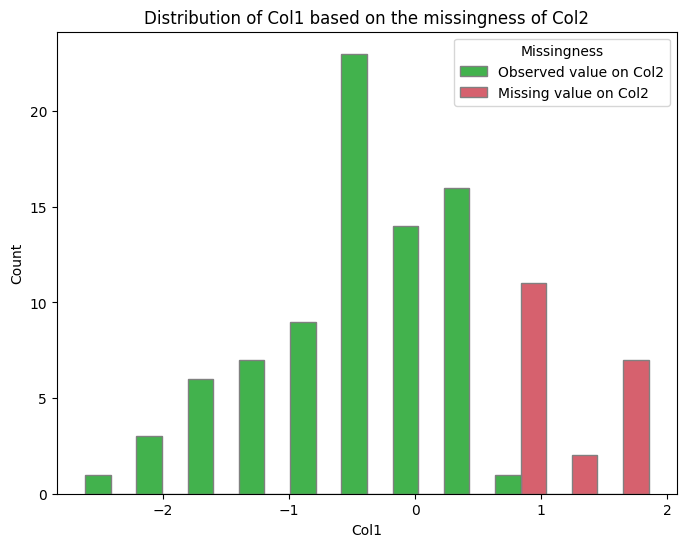

In [23]:
# Display the first plot
first_fig, first_ax = plots[0], plots[1]
first_fig

In this plot, it is suggested that Col2 has likely a MAR missing data mechanism, since its missing values depend on the values of Col1.

On the other hand, the next plot indicates that Col2 has no missingness relation with Col3.

Of course, additional testing should be done to confirm results.

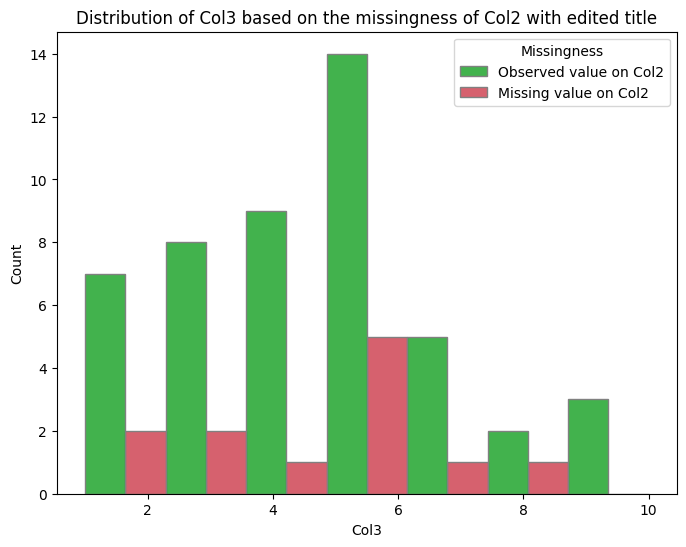

In [24]:
# Example of unpacking the first (fig, ax) from the flat tuple.
second_fig, second_ax = plots[2], plots[3]
second_ax.set_title(second_ax.get_title() + " with edited title")
second_fig

When encountering numeric data, `build_distribution_of_missingness()` uses `histplot()`. However, if the column has non-numeric data, then the function uses `countplot()`. In the case of `data_mix`, `numeric_col` is plotted using `histplot()`, while the distributions of `color_col` and `animal_col` use `countplot()`.

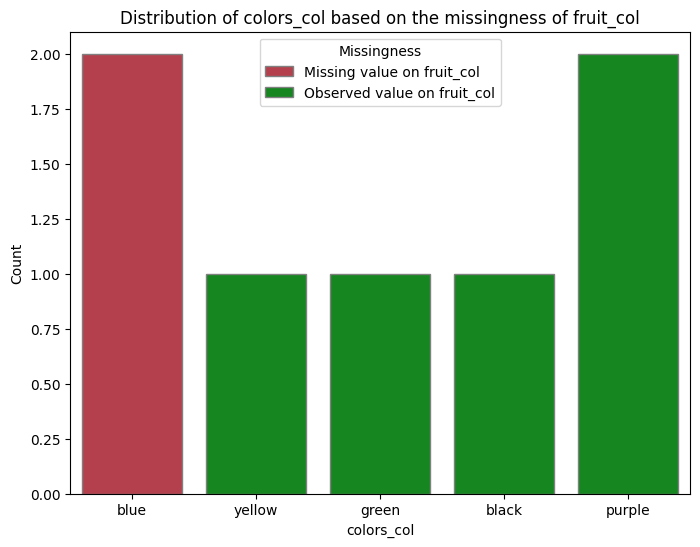

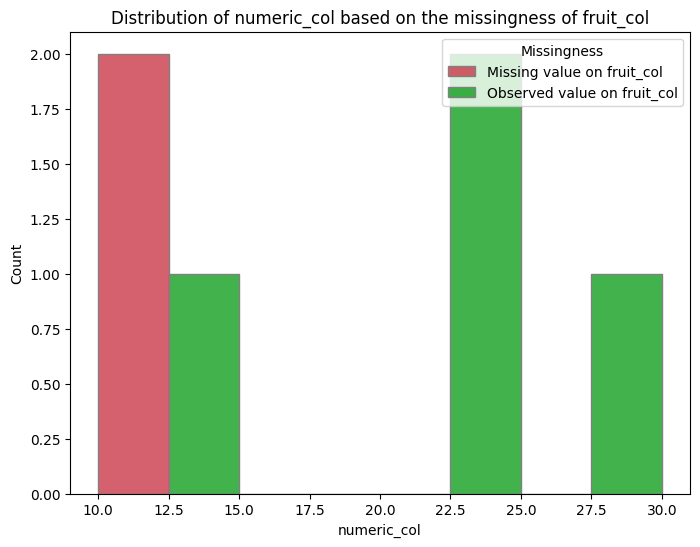

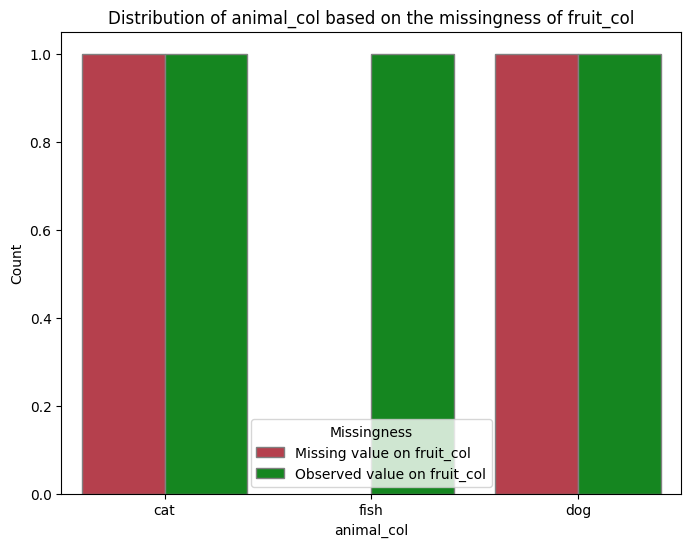

In [26]:
plots_mix = build_distribution_of_missingness(data_mix, "fruit_col", display_plot=True)